# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
# NOTE: this is no needed for Google Collab
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Understanding the structure of the data

In [ ]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')
# let colab access my google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Write your code here to read the data
data = pd.read_csv('/content/drive/My Drive/foodhub_order.csv')

In [ ]:
# Write your code here to view the first 5 rows
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here
print("There are", data.shape[0], 'rows and', data.shape[1], "columns in the data for FoodHub")
print("Output of data.shape tuple for dataframe food hub is: ", data.shape)

There are 1898 rows and 9 columns in the dataframe for FoodHub
Output of data.shape tuple for dataframe food hub is:  (1898, 9)


#### Observations:


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Write your code here
print(64 * "*")
print("Output of data.info() for data for FootHub is: ")
print(64 * "*")
data.info()
print(72 * "*")

****************************************************************
Output of data.info() for dataframe FootHub is: 
****************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB
************************************************************************


# Write your comments here
There are 9 numerical columns in the data.
4 are object type, 4 are int64, and 1 is float64.
Memory usage for the data frame is 133.6+ KB
day_of_the_week, food_preparation_time, and delivery_time are not time or date elements;
day_of_the_week only shows weekday and weekend and not exact day could be enumration type for exact date
and the times could be in sceonds/minutes time elements?


#### Observations:


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

all columns have 1898 entries but we can check for duplicates
some ratings are missing and skewed high toward 3 , 4 , 5 rating
Its seems only satisified customers leave high ratings and customer are hesitant to leave low ratings

In [ ]:
# Write your code here
print(f"Print null values for all columns in data frame")
print(data.isnull().sum())
print

Print null values for all columns in data frame
order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


<function print>

In [ ]:
# Write your code here
print(f"Iterate through data frame")
for column in data.columns:
    print(72 * "*")
    print(f"Column: {column}")
    # print(f"Unique Values for column: {column}")
    # print(data[column].unique())
    print(f"Value Counts for column: {column}")
    print(data[column].value_counts())



Iterate through data frame
************************************************************************
Column: order_id
Value Counts for column: order_id
order_id
1477147    1
1477697    1
1477555    1
1478028    1
1478308    1
          ..
1478087    1
1476775    1
1478421    1
1476774    1
1478056    1
Name: count, Length: 1898, dtype: int64
************************************************************************
Column: customer_id
Value Counts for column: customer_id
customer_id
52832     13
47440     10
83287      9
250494     8
259341     7
          ..
385426     1
254913     1
289597     1
74412      1
397537     1
Name: count, Length: 1200, dtype: int64
************************************************************************
Column: restaurant_name
Value Counts for column: restaurant_name
restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
             

#### Observations:


all columns have 1898 entries but we can check for duplicates some ratings are missing and skewed high toward 3 , 4 , 5 rating Its seems only satisified customers leave high ratings and customer are hesitant to leave low ratings

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here
data.describe().T


,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:


### **Question 5:** How many orders are not rated? [1 mark]

************************************************************************
rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64
************************************************************************
Bar chart for column rating in data frame:
************************************************************************


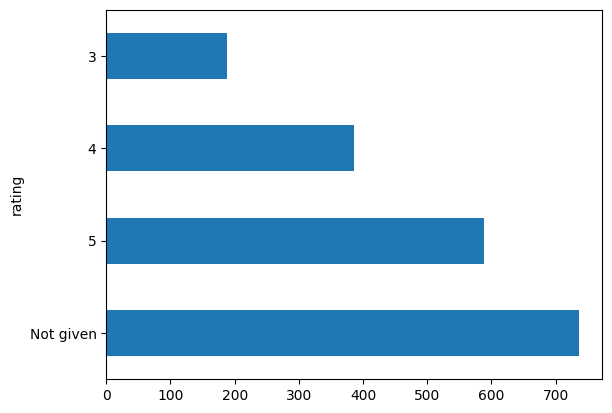

In [ ]:
# Write the code here
print(72 * "*")
print(data['rating'].value_counts())
print(72 * "*")
print(f"Bar chart for column rating in data frame:")
print(72 * "*")
data['rating'].value_counts().plot(kind='barh');

#### Observations: 736 order are not given a rating. The remaning 1162 orders were rating 3-5. 5 being the most rate given by customers and 3 being the lowest rate given by customers.
some ratings are missing and skewed high toward 3 , 4 , 5 rating Its seems only satisified customers leave high ratings and customer are hesitant to leave low ratings

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

the number of unique orders 1898
the number of unique customers 1200


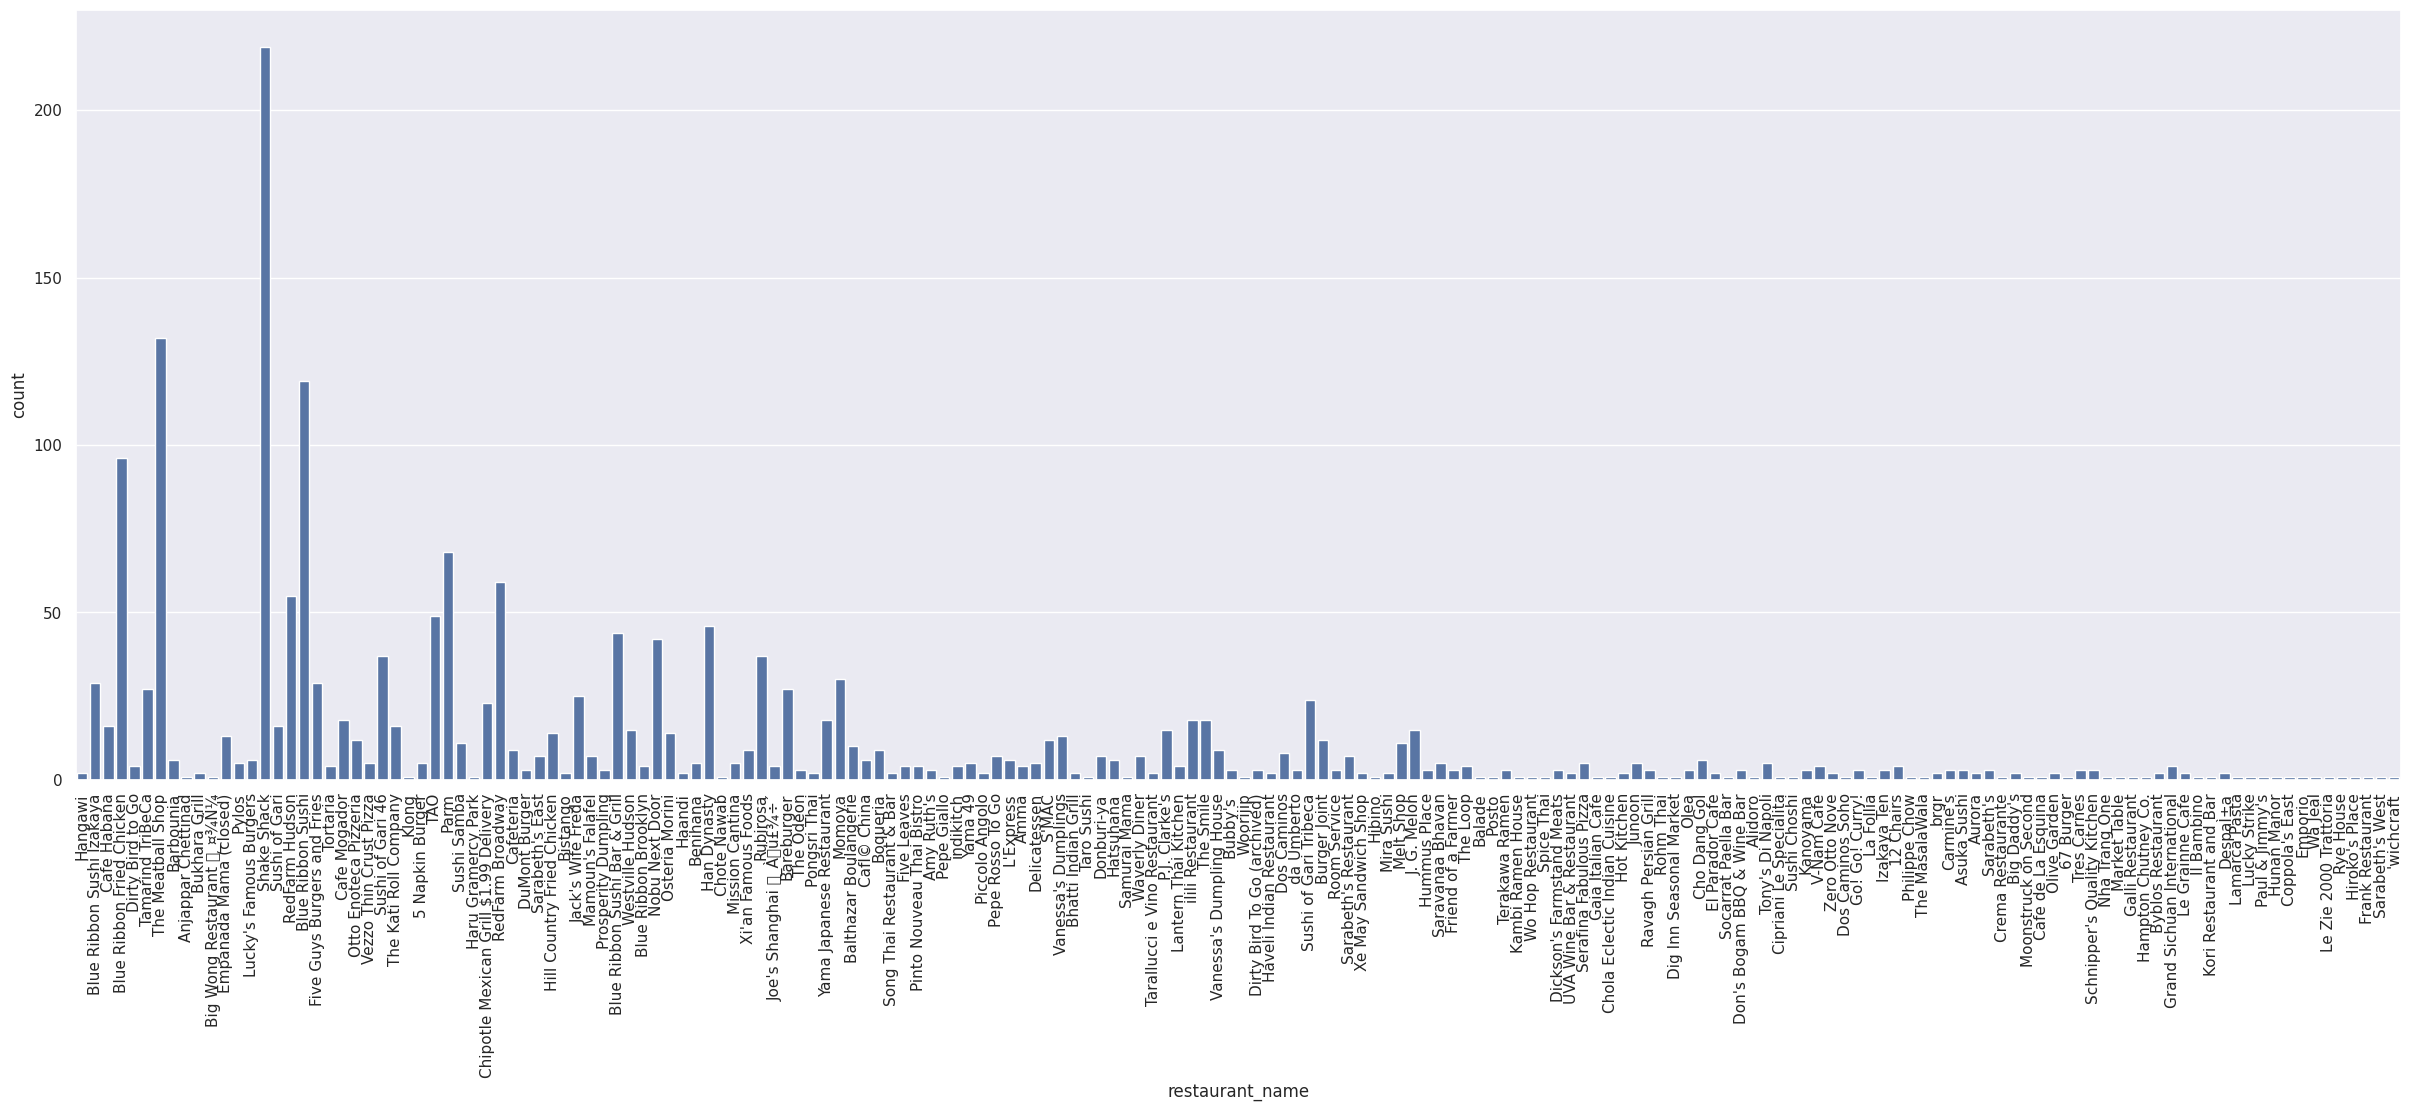

<Axes: xlabel='day_of_the_week', ylabel='count'>

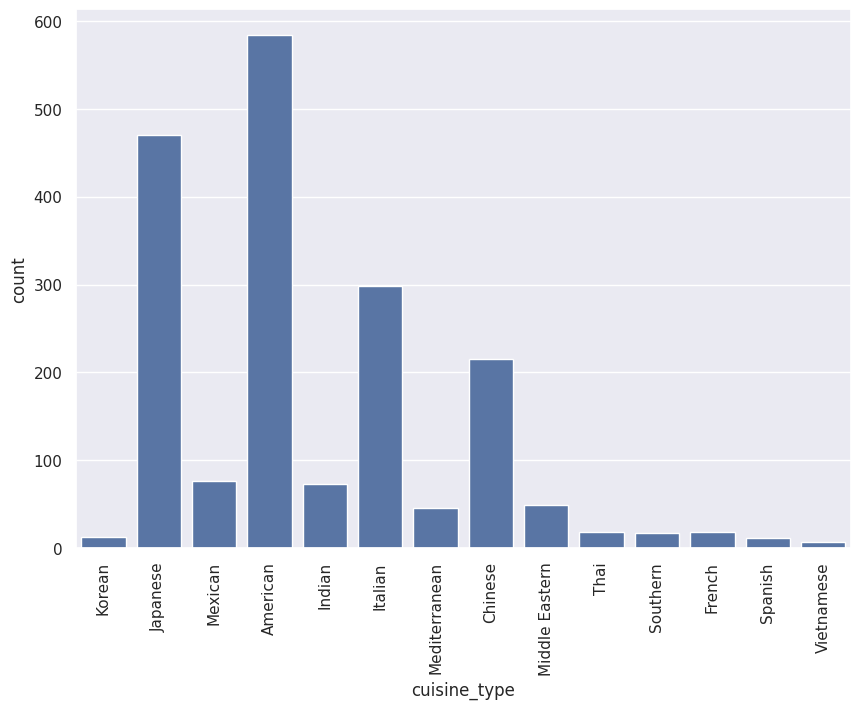

<Figure size 800x500 with 0 Axes>

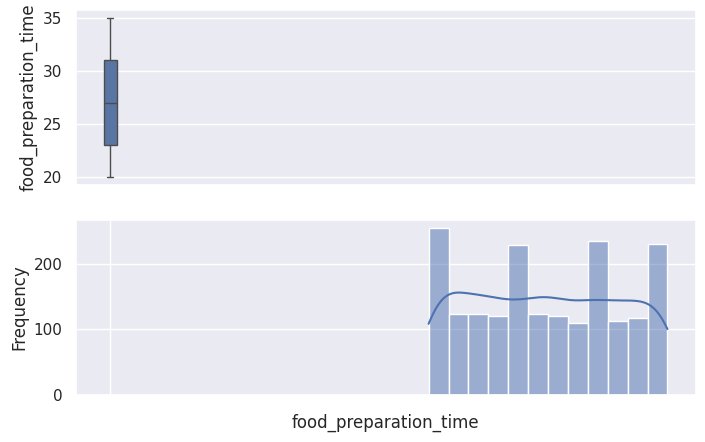

<Figure size 800x500 with 0 Axes>

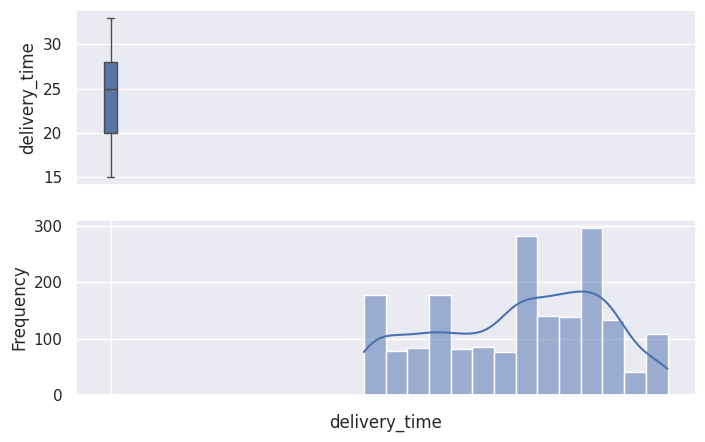

<Figure size 800x500 with 0 Axes>

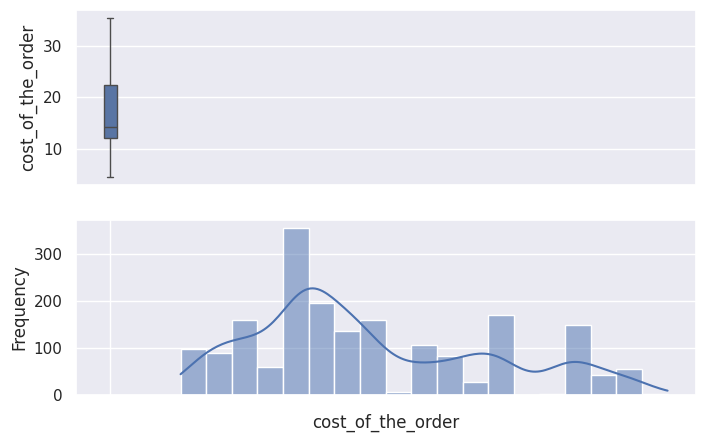

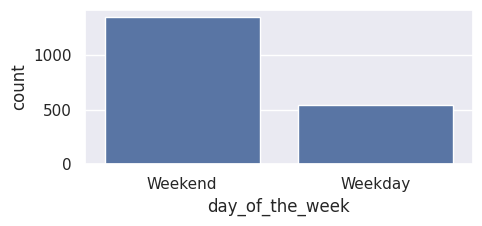

In [ ]:
# Write the code here
# order id
# check the count of unique number of order id, value counts
order_unique = data['order_id'].nunique()
print(f'the number of unique orders', order_unique)
# customer id
# check the count of unique number of order id, value counts
customer_unique = data['customer_id'].nunique()
print(f'the number of unique customers', customer_unique)
# restaurant name
# check the count of unique number of restaurant name, value counts, countplot
data['restaurant_name'].nunique()
restaurant_name_counts = data["restaurant_name"].value_counts
restaurant_name_counts()
plt.figure(figsize=(30,10))
sns.countplot(data, x='restaurant_name')
plt.xticks(rotation=90);
plt.show()
# cuisine Type
# check the count of unique number of cuisine type, value counts, and countplot.
data['cuisine_type'].nunique()
cuisine_type_counts = data["cuisine_type"].value_counts
cuisine_type_counts()
plt.figure(figsize=(10,7))
sns.countplot(data, x='cuisine_type')
plt.xticks(rotation=90);
# food_preparation_time
# boxplot and histplot.
i = "food_preparation_time"
plt.figure()
plt.tight_layout()
sns.set(rc={"figure.figsize":(8, 5)})
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True)
plt.gca().set(xlabel= i,ylabel='Frequency')
sns.boxplot(data[i], ax=ax_box , linewidth= 1.0);
sns.histplot(data[i], ax=ax_hist , kde=True);
# delivery_time
# boxplot and histplot.
i = "delivery_time"
plt.figure()
plt.tight_layout()
sns.set(rc={"figure.figsize":(8, 5)})
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True)
plt.gca().set(xlabel= i,ylabel='Frequency')
sns.boxplot(data[i], ax=ax_box , linewidth= 1.0);
sns.histplot(data[i], ax=ax_hist , kde=True);
# cost_of_the_order
# boxplot and histplot.
i = "cost_of_the_order"
plt.figure()
plt.tight_layout()
sns.set(rc={"figure.figsize":(8, 5)})
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True)
plt.gca().set(xlabel= i,ylabel='Frequency')
sns.boxplot(data[i], ax=ax_box , linewidth= 1.0);
sns.histplot(data[i], ax=ax_hist , kde=True);
# day_of_the_week
# check the count of unique number of Days of the week, and countplot.
data['day_of_the_week'].nunique()
plt.figure(figsize = (5,2))
sns.countplot(data, x = 'day_of_the_week')
# rating
# check the count of unique number of rating, value_counts and countplot.
data['rating'].nunique()
rating_counts = df["rating"].value_counts
rating_counts()
plt.figure(figsize=(5,2))
sns.countplot(data, x='rating');

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

********************************************************************************
Print the value counts for all in ascending order for:  restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64
********************************************************************************
Print a chart of top 5 restaurants in terms of the number of orders received: 
********************************************************************************


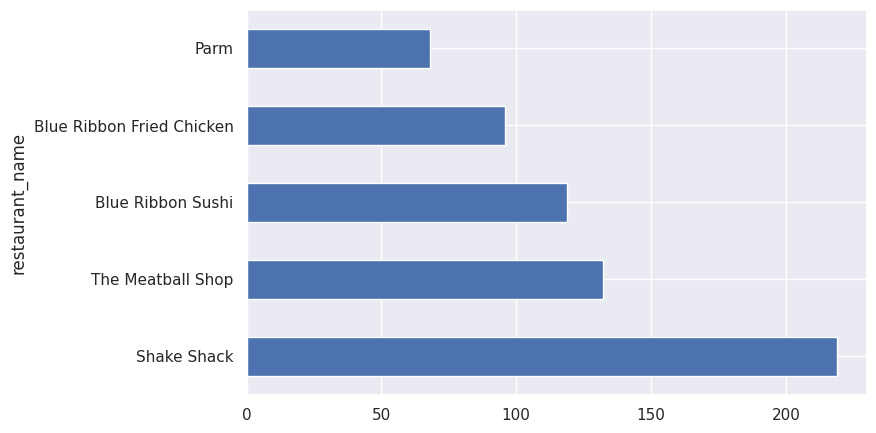

In [ ]:
# Write the code here
print(80 * "*")
print(f"Print the value counts for all in ascending order for: ",data['restaurant_name'].value_counts().iloc[:5])
print(80 * "*")
print(f"Print a chart of top 5 restaurants in terms of the number of orders received: ")
print(80 * "*")
# data['restaurant_name'].value_counts().plot(kind='barh');
#find values with top 5 occurrences store in top_5_restaurants
top_5_restaurants = (data['restaurant_name'].value_counts()).iloc[:5]
#top_5_using_head = (data['restaurant_name'].value_counts()).head(5)
#create bar chart to visualize top 5 occurrence
top_5_restaurants.plot(kind='barh');
#top_5_using_head.plot(kind='barh');

# **Observation**:
#
# **Popular Restaurants:** Shake Shack seems to be the most popular restaurant with 219 orders, followed by The Meatball Shop and Blue Ribbon Sushi. These restaurants might be offering popular cuisines, have high customer satisfaction, and/or run effective promotions.
#
# **Potential Business Insights:** FoodHub might want to investigate why some restaurants are receiving fewer orders. It could be due to **various reasons** like **cuisine type, price, customer service, delivery time, etc**. Addressing these issues could potentially increase their popularity and orders.
#
# **Promotion and Partnership Opportunities:** FoodHub could be opportunity for FoodHub to **promote lesser-known or newer restaurants** to help increase their visibility and orders. Alternatively, FoodHub might want to form **strategic partnerships** with the most popular restaurants, given their apparent success on the platform.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

************************************************************************
cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64
************************************************************************
Bar chart for column rating in data frame:
************************************************************************


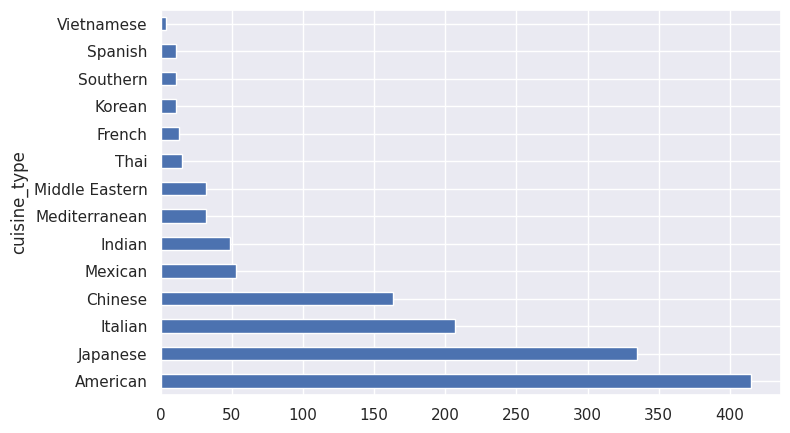

In [ ]:
# Write the code here
print(72 * "*")
print(data['cuisine_type'].value_counts())
print(72 * "*")
print(f"Bar chart for column rating in data frame:")
print(72 * "*")
# data['cuisine_type'].value_counts().plot(kind='barh');
df_weekend = data[data['day_of_the_week'] == 'Weekend']
cuisine_counts_weekend = df_weekend['cuisine_type'].value_counts()
cuisine_counts_weekend.plot(kind='barh');

#### Observations:


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
data_order_more_than_twenty = data[data['cost_of_the_order']>20]
total_orders_over_twenty = data_order_more_than_twenty.shape[0]
print('The total number of orders that cost more than 20 dollars is:', total_orders_over_twenty)
total_orders = data.shape[0]
percentage_over_twenty = (total_orders_over_twenty / total_orders) * 100
print("Percentage of orders that cost more than 20 dollars:", round(percentage_over_twenty, 2), '%')


The total number of orders that cost more than 20 dollars is: 555
Percentage of orders that cost more than 20 dollars: 29.24 %


#### Observations:


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here
mean_delivery_time = data['delivery_time'].mean()
print(f'The mean order delivery time is', round(mean_delivery_time, 2), f'minutes')

The mean order delivery time is 24.16 minutes


#### Observations:


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
top_three_frequent_customers = data['customer_id'].value_counts().head(3)
print(f'The top three most frequent customers and there order counts: ', top_three_frequent_customers)

The top three most frequent customers and there order counts customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


#### Observations:


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


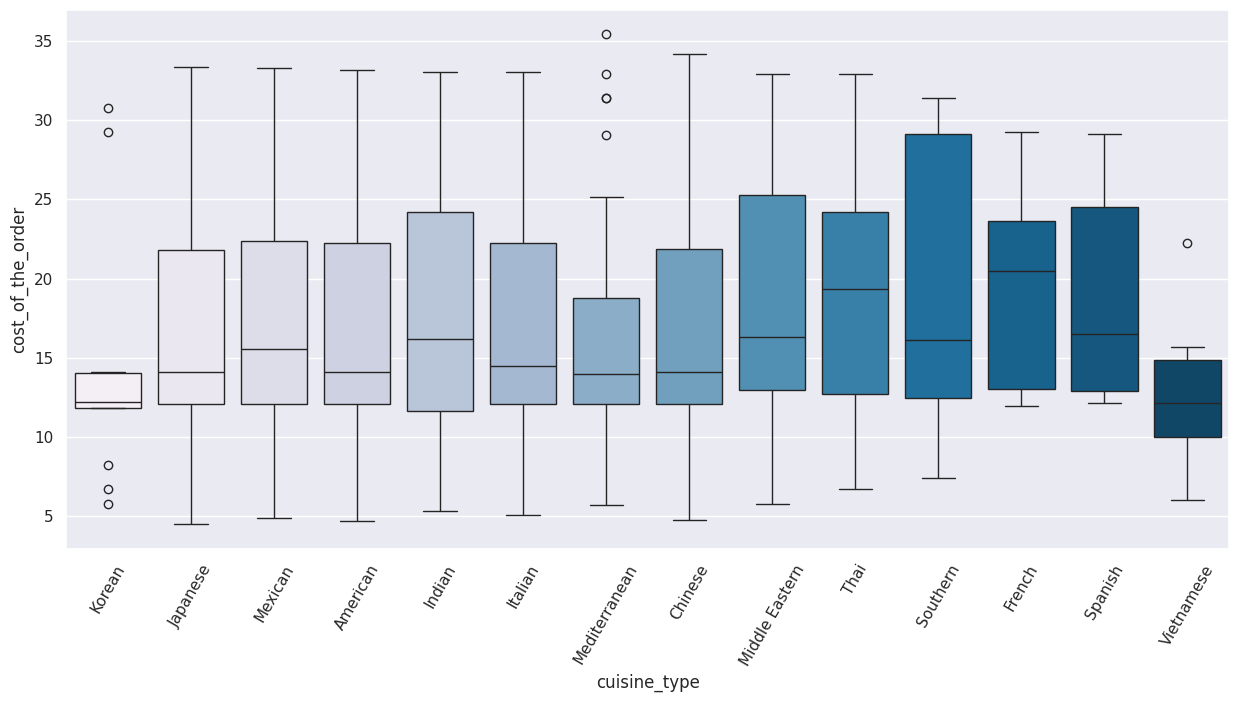

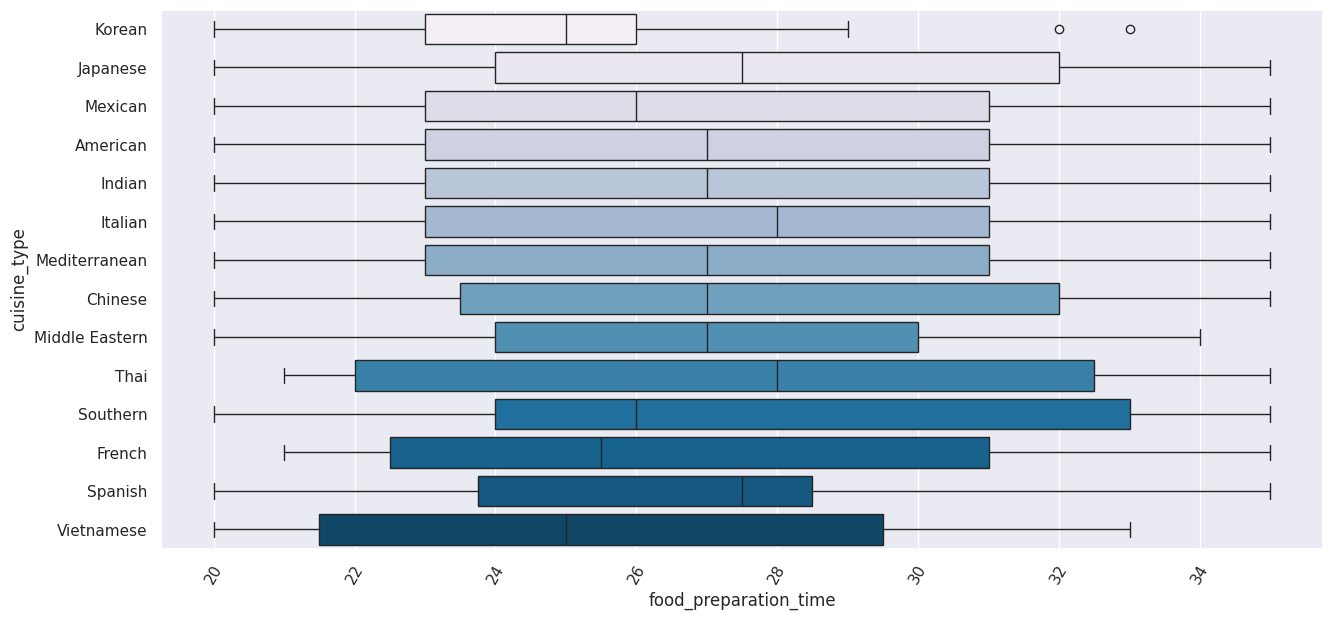

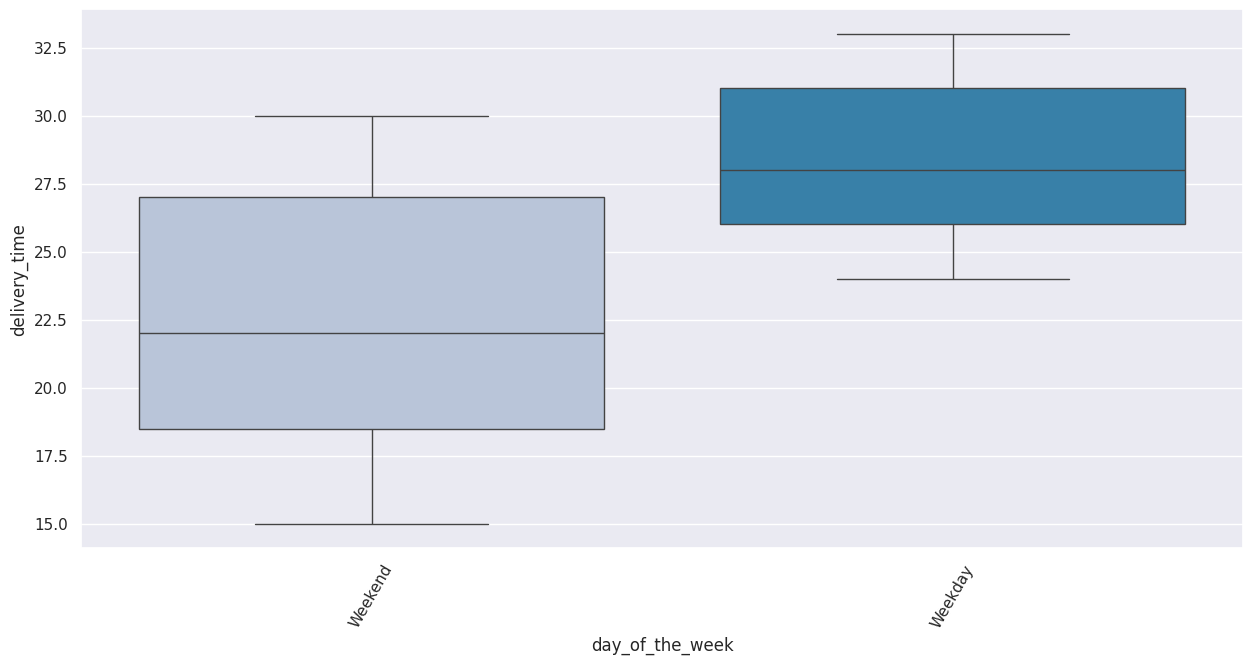

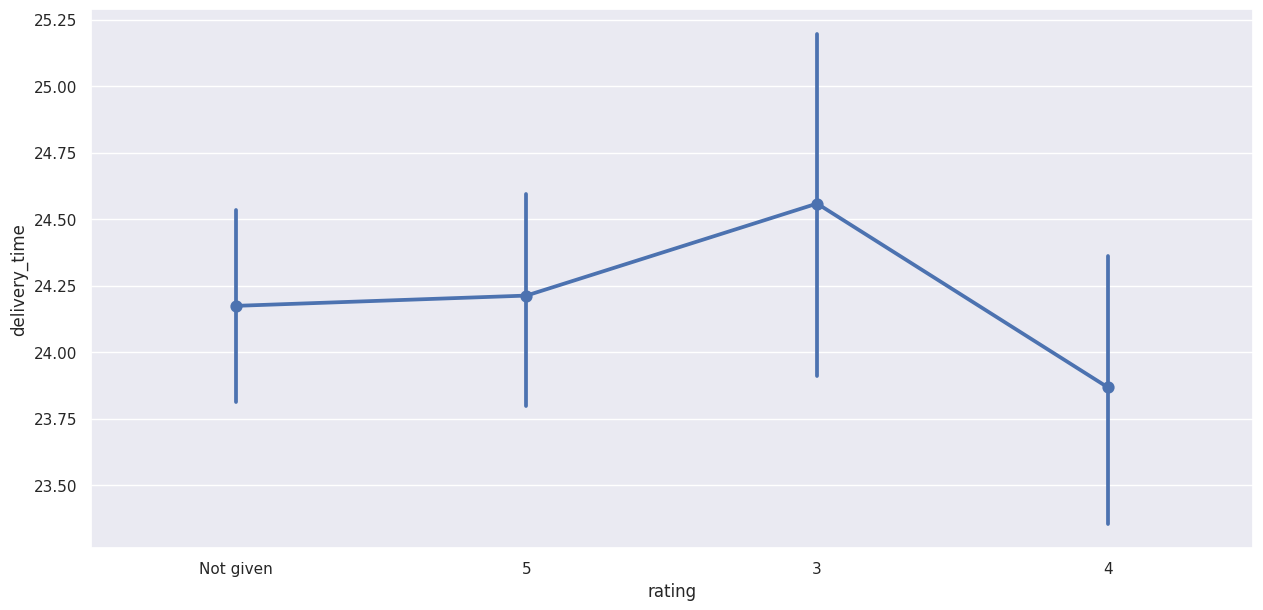

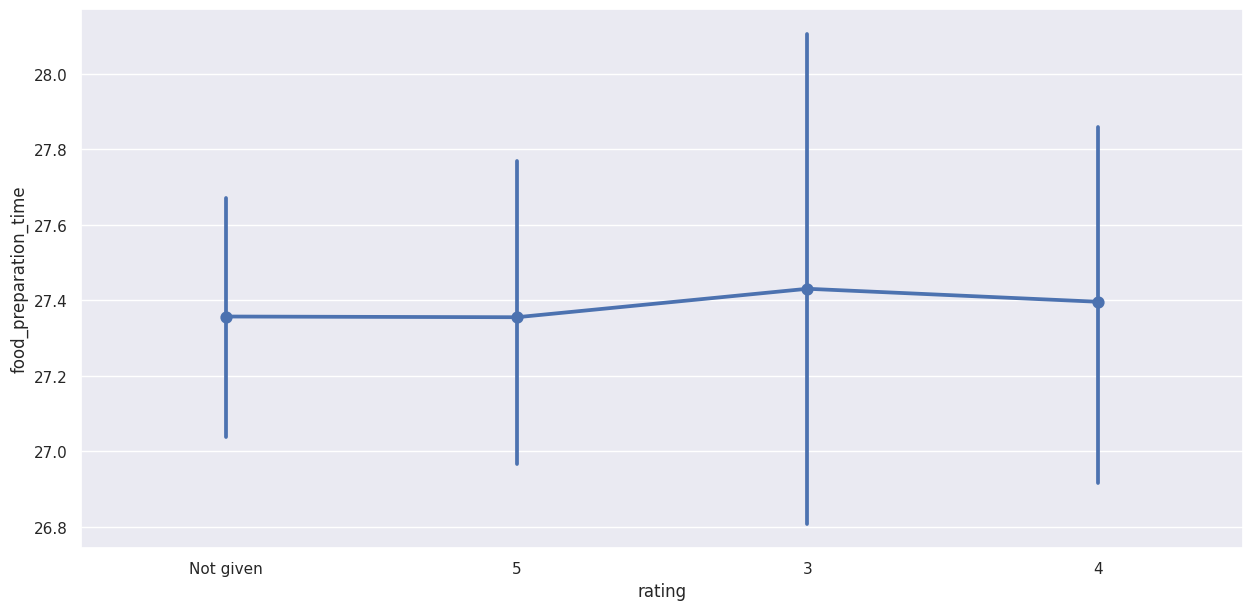

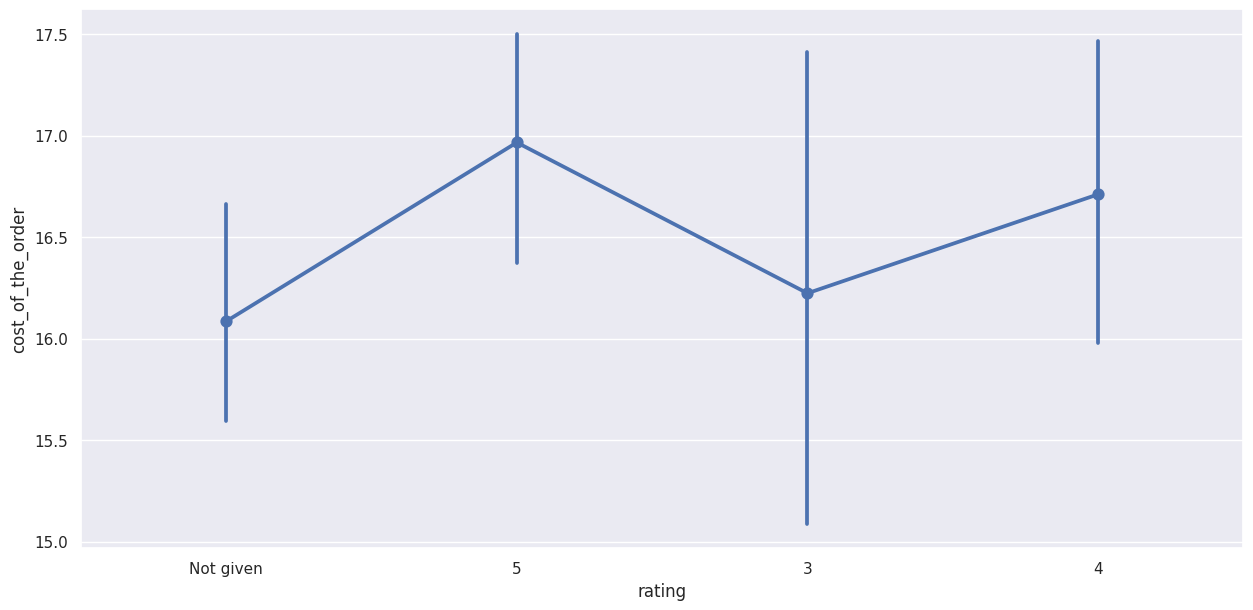

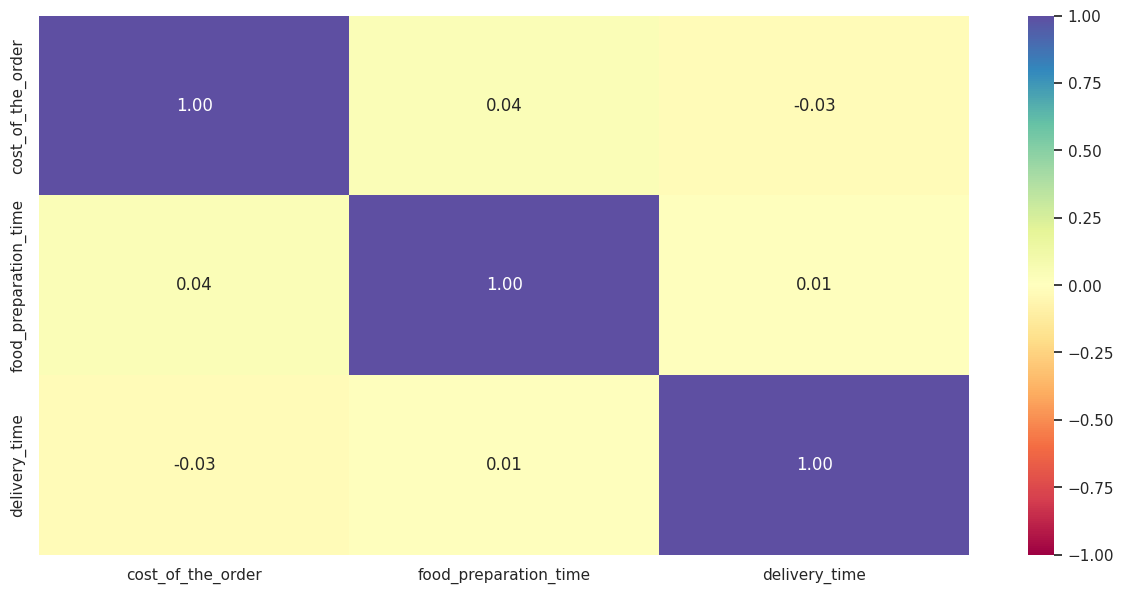

In [ ]:
# Write the code here
# relationship between cuisine_type and cost_of_order
xfield = "cuisine_type"
yfield = "cost_of_the_order"
plt.figure()
plt.tight_layout()
sns.set(rc={"figure.figsize":(15, 7)})
sns.boxplot(data, x = xfield, y = yfield,  palette = 'PuBu')
plt.xticks(rotation = 60)
plt.show();
# relationship between food_preparation_time and cuisine_type
xfield = "food_preparation_time"
yfield = "cuisine_type"
plt.figure()
plt.tight_layout()
sns.set(rc={"figure.figsize":(15, 7)})
sns.boxplot(data, x = xfield, y = yfield,  palette = 'PuBu')
plt.xticks(rotation = 60)
plt.show();
# relationship between day_of_the_week and delivery_time
xfield = 'day_of_the_week'
yfield = 'delivery_time'
plt.figure()
plt.tight_layout()
sns.set(rc={"figure.figsize":(15, 7)})
sns.boxplot(data, x = xfield, y = yfield,  palette = 'PuBu')
plt.xticks(rotation = 60)
plt.show();
# relationship between rating and delivery_time
xfield = 'rating'
yfield = 'delivery_time'
plt.figure(figsize=(15, 7))
sns.pointplot(data, x = xfield, y = yfield)
plt.show();
# relationship between rating and food_preparation_time
xfield = 'rating'
yfield = 'food_preparation_time'
plt.figure(figsize=(15, 7))
sns.pointplot(data, x = xfield, y = yfield)
plt.show()
# relationship between rating and cost_of_the_order
xfield = 'rating'
yfield = 'cost_of_the_order'
plt.figure(figsize=(15, 7))
sns.pointplot(data, x = xfield, y = yfield)
plt.show();
# correlation between all variables - heatmap
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(15, 7))
sns.heatmap(data[col_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show();

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Write the code here
df_rated = data[data['rating'] != 'Not given'].copy()
df_rated['rating'] = df_rated['rating'].astype('int')
df_rating_count = df_rated.groupby(['restaurant_name'])['rating'].count().sort_values(ascending = False).reset_index()
df_rating_count.head()
rest_names = df_rating_count[df_rating_count['rating'] > 50]['restaurant_name']
df_mean_4 = df_rated[df_rated['restaurant_name'].isin(rest_names)].copy()
df_mean_4.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending = False).reset_index().dropna()

,restaurant_name,rating
0,The Meatball Shop,4.511905
1,Blue Ribbon Fried Chicken,4.328125
2,Shake Shack,4.278195
3,Blue Ribbon Sushi,4.219178


#### Observations:


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Write the code here
def compute_rev(x):
    if x > 20:
        return x*0.25
    elif x > 5:
        return x*0.15
    else:
        return x*0


data['Revenue'] = data['cost_of_the_order'].apply(compute_rev)
total_rev = data['Revenue'].sum()
print('The net revenue is around', round(total_rev, 2), 'dollars')

The net revenue is around 6166.3 dollars


#### Observations:


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here
data['total_time'] = data['food_preparation_time'] + data['delivery_time']
df_greater_than_60 = data[data['total_time']>60]
print('The total number of orders that took more than 60 minutes to get delivered is:', df_greater_than_60.shape[0])
percentage = (df_greater_than_60.shape[0] / data.shape[0]) * 100
print("Percentage of orders that took more than 60 minutes to get delivered:", round(percentage, 2), '%')


The total number of orders that took more than 60 minutes to get delivered is: 200
Percentage of orders that took more than 60 minutes to get delivered: 10.54 %


#### Observations:


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Write the code here
print('The mean delivery time on weekends is around',
      round(data[data['day_of_the_week'] == 'Weekend']['delivery_time'].mean()),
     'minutes')
print('The mean delivery time on weekdays is around',
      round(data[data['day_of_the_week'] == 'Weekday']['delivery_time'].mean()),
     'minutes')


The mean delivery time on weekends is around 22 minutes
The mean delivery time on weekdays is around 28 minutes


#### Observations:


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  

### Recommendations:

*  

---